In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, freqz, lfilter, filtfilt, iirnotch, butter, resample_poly, correlate, get_window
from sklearn.decomposition import PCA


%matplotlib widget


In [2]:
data = pd.read_csv('set-b-text/b60.csv',skiprows=[0,1],names=['time','channel1','channel2','channel3','channel4'],)
# QRSpostions = np.loadtxt('set-a-text/a21.fqrs.txt',dtype=int,)

In [57]:
data.head()

,time,channel1,channel2,channel3,channel4
0,0.000,51.5,32.5,37.5,20.0
1,0.001,50.5,31.5,36.5,19.5
2,0.002,49.5,29.5,35.0,18.0
3,0.003,48.5,28.0,33.0,17.5
4,0.004,47.0,26.0,31.5,16.5


In [3]:
#check original data sampling rate
time_diffs = data["time"].diff().dropna()
estimated_fs = 1 / time_diffs.mean()

estimated_fs

np.float64(1000.0)

In [ ]:
def changeSamplingRate(df: pd.DataFrame, original_fs: int = 1000, target_fs: int = 400,plot_result = False) -> pd.DataFrame:
    """
    Change the sampling rate of a DataFrame containing time series data.
    
    Args:
        df (pd.DataFrame): DataFrame with a 'time' column and other signal columns.
        original_fs (int): Original sampling frequency in Hz.
        target_fs (int): Target sampling frequency in Hz.
        plot_result (bool): Whether to plot the original and resampled signals.
        
    Returns:
        pd.DataFrame: DataFrame with the resampled data.
    """
    # Calculate the upsampling factor
    upsample_factor = target_fs / original_fs
    
    # Initialize a new dictionary to store resampled data
    resampled_data = {}

    original_time = df['time'].values
    total_duration = original_time[-1]  # Total time duration in seconds
    new_sample_count = int(len(original_time) * upsample_factor)
    resampled_data['time'] = np.linspace(0, total_duration, new_sample_count)

    for col in df.columns:
        if col != 'time':
             # Resample the signal using polyphase resampling
            resampled_data[col] = resample_poly(df[col], up=target_fs, down=original_fs)


    if plot_result:
        channel_to_plot = df.columns[1] 

        plt.figure(figsize=(10, 4))
        plt.plot(df.time, df[channel_to_plot],label=f"Original {channel_to_plot} ({original_fs} Hz)",)
        plt.plot(resampled_data['time'], resampled_data[channel_to_plot], label=f"Target {channel_to_plot} ({target_fs} Hz)", alpha=0.5)
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.title(f"Change sampling rate {channel_to_plot}: {original_fs} Hz → {target_fs} Hz")
        plt.grid()
        plt.show()  

    return pd.DataFrame(resampled_data)

In [5]:
s1 = changeSamplingRate(data, original_fs=1000, target_fs=400,plot_result=False)
sampling_rate = 400

In [6]:
def clean_data(fecg_df:pd.DataFrame)->pd.DataFrame:
    """
    This function takes a dataframe of FECG and clean it by removing the NaN values and convert the values to numeric.
    """
    for i in fecg_df.columns:
        fecg_df[i] = pd.to_numeric(fecg_df[i], errors='coerce').fillna(0)
    return fecg_df

In [7]:
s1 = clean_data(s1)

In [ ]:
def plot_filter_response(freq,freq_resp):
    """
    Plot the magnitude and phase response of the filter.
    """
    angles = np.unwrap(np.angle(freq_resp))  
    # Magnitude response
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(freq, 20 * np.log10(abs(freq_resp)))
    plt.title('Magnitude Response of the High-Pass FIR Filter')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude (dB)')
    plt.xlim([0, 50])  # Match paper's x-axis
    plt.ylim([-40, 10])  # Match paper's y-axis
    plt.grid()

    # Phase response
    plt.subplot(1, 2, 2)
    plt.plot(freq, angles, linewidth=1.5)
    plt.title('Phase Response of the High-Pass FIR Filter')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Phase (degree)')
    plt.grid()
    plt.xlim([0, 50])
    plt.ylim([-600, 0])  # Limit the y-axis for better visualization
    plt.show()

In [10]:
def wander_removal(signal, cutoff=3.0, fs=sampling_rate, num_taps=1001, 
                   plot_filter_coefs=False, plot_filter_resp=False, plot_result=False):
    """
    Apply a high-pass filter to remove baseline wander from the ECG signal.

    :param signal: ECG signal (numpy array)
    :param cutoff: Cut-off frequency (Hz)
    :param fs: Sampling frequency (Hz)
    :param num_taps: Number of taps (filter length, must be odd for FIR filter)
    :param plot_filter_coefs: Plot the filter coefficients
    :param plot_filter_resp: Plot the frequency response of the filter
    :param plot_result: Plot the original and filtered signals

    :return: Filtered signal
    """
    signal = np.asarray(signal, dtype=np.float64)

    # Design the high-pass FIR filter
    filter_taps = firwin(num_taps, cutoff, fs=fs, pass_zero="highpass", window='hamming')

    # Plot the filter coefficients
    if plot_filter_coefs:
        plt.figure()
        plt.plot(filter_taps, '.-')
        plt.xlabel('Index')
        plt.ylabel('Amplitude')
        plt.title(f'High-Pass FIR Filter Coefficients ({num_taps} taps)')
        plt.grid()
        plt.show()

    # Compute frequency response
    freq, freq_resp = freqz(filter_taps, worN=1024, fs=fs)
    
    if plot_filter_resp:
        # Compute filter delay
        delay_samples = (num_taps - 1) / 2  # FIR filter delay
        delay_time = delay_samples / fs  # Convert to seconds
        print(f"Filter Delay: {delay_samples} samples ({delay_time:.4f} sec)")

        # Plot frequency response
        plot_filter_response(freq, freq_resp)

    # Apply the filter to the signal
    # Preserves true shape (with constant delay)
    filtered_signal = lfilter(filter_taps, 1.0, signal)


    if plot_result:
        time = np.arange(len(signal)) / fs
        plt.figure(figsize=(12, 4))
        plt.plot(time, signal, label="Original Signal")
        plt.plot(time, filtered_signal, label="Filtered Signal", linewidth=1.5)
        plt.title("Signal Before and After High-Pass Filtering")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid()
        plt.show()

    return filtered_signal

In [65]:
def baseline_wander_remover(fecg_df:pd.DataFrame)->pd.DataFrame:
    """
    This function takes a dataframe of FECG and apply a high-pass filter to remove the baseline wander.
    """
    dummy_df = fecg_df.copy()
    for i in dummy_df.columns:
        if(i != 'time'):
            dummy_df[i] = wander_removal(dummy_df[i],fs=sampling_rate,plot_filter_resp=False,plot_result=True,plot_filter_coefs=False)
    dummy_df = dummy_df.iloc[500:]  # Remove the first 500 samples for the delay
    dummy_df.reset_index(drop=True, inplace=True)
    return dummy_df

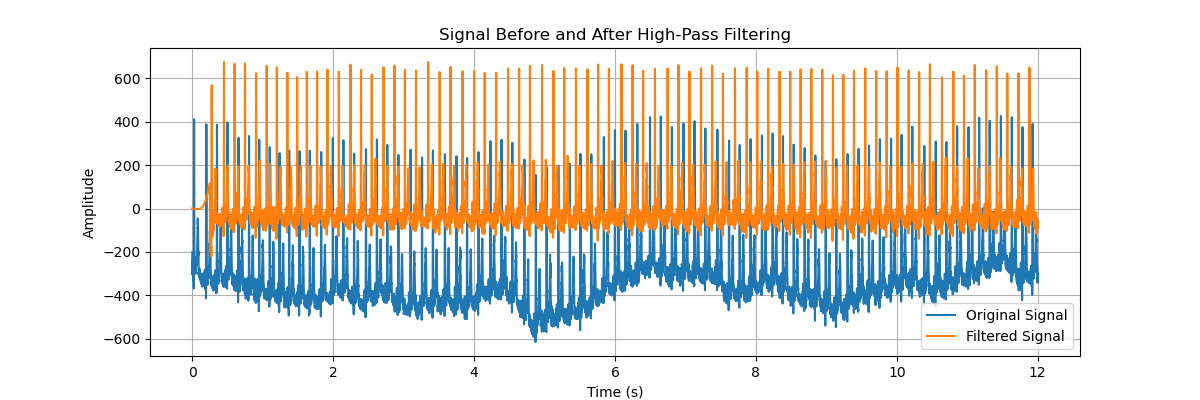

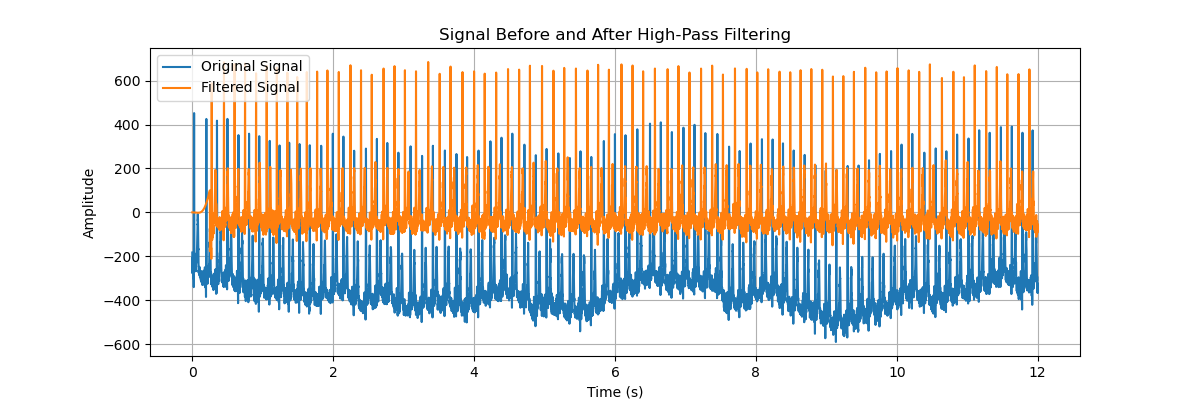

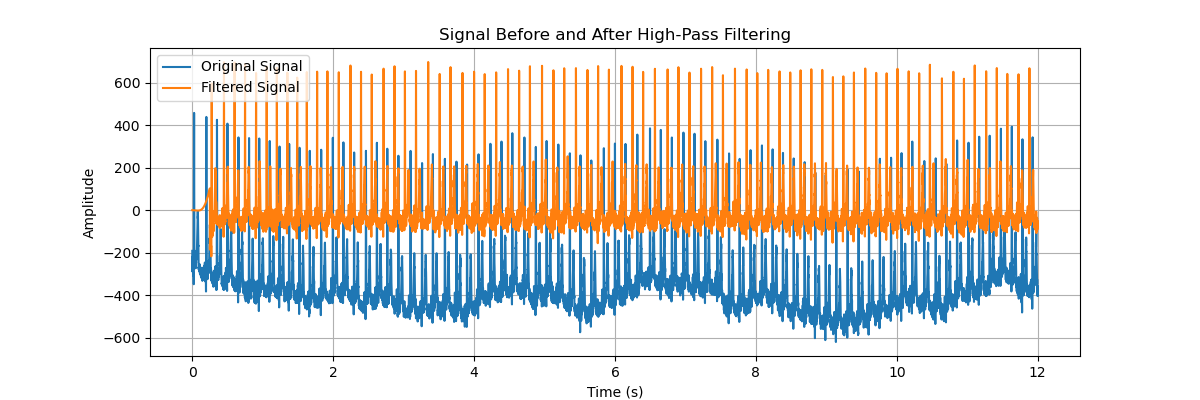

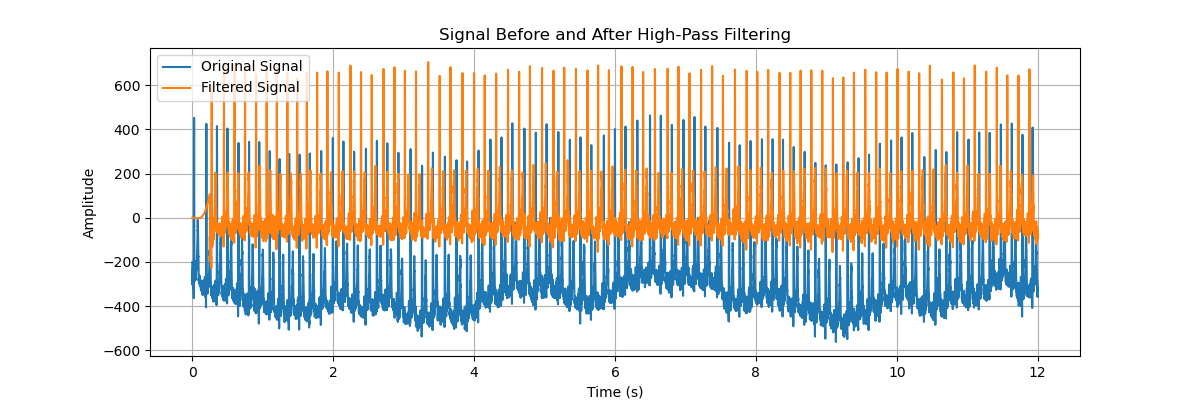

In [66]:
s2 = baseline_wander_remover(s1)

In [108]:
s2.head()

,time,channel1,channel2,channel3,channel4
500,1.250031,15.131807,11.009207,9.857193,6.270065
501,1.252531,31.943217,19.557403,20.454714,11.613903
502,1.255031,23.121469,11.742029,12.349513,7.402740
503,1.257531,25.074321,11.578892,13.222153,7.614299
504,1.260032,22.984333,10.172702,11.653584,6.926393


In [ ]:

def check_noise(signal, fs=400, harmonics=[50, 100, 150, 200]):
    """
    Check for strong frequency components at 50 Hz or its harmonics in the signal.
    :param signal: Input signal
    :param fs: Sampling frequency (Hz)
    :param harmonics: List of harmonics to check (default is [50, 100, 150, 200])
    """
    # Perform FFT
    fft_result = np.fft.fft(signal)
    fft_freq = np.fft.fftfreq(len(signal), d=1/fs)  

    # Plot the FFT result
    plt.figure(figsize=(12, 6))
    plt.plot(fft_freq[:len(fft_freq)//2], np.abs(fft_result)[:len(fft_result)//2])
    plt.title('FFT of the Signal')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid()
    plt.show()

    # Check for strong frequency components at 50 Hz or its harmonics
    for harmonic in harmonics:
        idx = np.argmin(np.abs(fft_freq - harmonic))
        print(f"Frequency: {fft_freq[idx]:.2f} Hz, Magnitude: {np.abs(fft_result[idx]):.2f}")


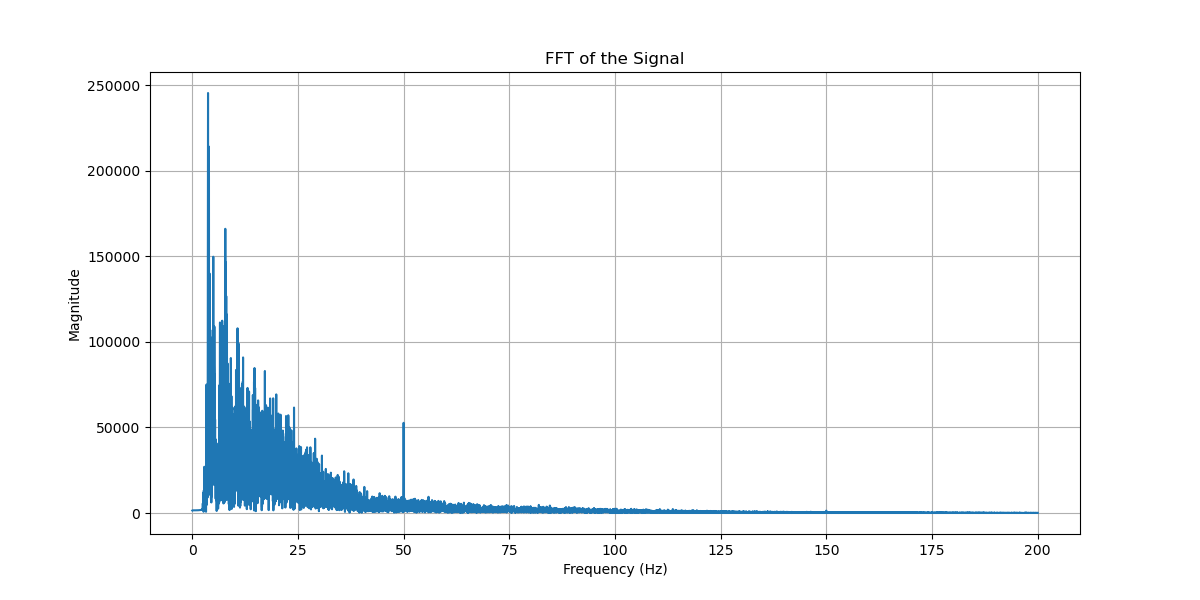

Frequency: 49.99 Hz, Magnitude: 52701.76
Frequency: 100.00 Hz, Magnitude: 2507.10
Frequency: 149.99 Hz, Magnitude: 302.46
Frequency: 199.98 Hz, Magnitude: 74.23


In [15]:
check_noise(s2.channel1, fs=sampling_rate)

In [ ]:
def multi_channel_PLIC(signal, powerline_freq=50, fs=400, harmonics=4, plot_response=False):
    """
    Apply multiple notch filters to remove power-line interference and its harmonics.

    :param signal: Input ECG signal (numpy array)
    :param powerline_freq: Power-line frequency (Hz) (default: 50 Hz)
    :param fs: Sampling frequency (Hz) (default: 400 Hz)
    :param harmonics: Number of harmonics to remove (e.g., 3 removes 50, 100, 150 Hz)
    :param quality_factor: Quality factor of the notch filters (default: 30)
    :param plot_response: If True, plots the frequency response of the filter
    :return: Filtered signal
    """
    
    filtered_signal = signal.copy()

    if plot_response:
        plt.figure(figsize=(10, 5))
    
    for i in range(1, harmonics + 1):
        notch_freq = powerline_freq * i  # Compute harmonic frequency
        quality_factor = 20 #higher Q = narrower filter , ower Q = wider filter
        b, a = iirnotch(notch_freq, quality_factor,fs=fs) 

        # filtfilt applies the filter forward and backward, cancelling phase distortion.
        #  This ensures that the ECG signal's important features, like the QRS complexes,
        #  are not shifted or distorted by the filtering. Since I am using an IIR notch filter to efficiently remove narrow-band noise,
        #  filtfilt helps me maintain zero phase without introducing a time delay.
        filtered_signal = filtfilt(b, a, filtered_signal)

        # Plot frequency response
        if plot_response:
            w, h = freqz(b, a, fs=fs)
            #Magnitude (dB)=20×log(10(abs(h)))
            plt.plot(w, 20 * np.log10(abs(h)), label=f'Notch at {notch_freq} Hz')

    if plot_response:
        plt.axvline(powerline_freq, color='r', linestyle='--', label='Fundamental')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Magnitude (dB)')
        plt.title('Notch Filter Frequency Response')
        plt.legend()
        plt.grid()
        plt.show()

    return filtered_signal

def Multi_Power_line_interference_canceller(fecg_df:pd.DataFrame)->pd.DataFrame:
    """
    This function takes a dataframe of ECG and apply a notch filter to remove the power-line interference.
    """
    dummy = fecg_df.copy()
    for i in dummy.columns:
        if(i != 'time'):
            dummy[i] = multi_channel_PLIC(dummy[i])
    return dummy



In [17]:
s3 = Multi_Power_line_interference_canceller(s2)

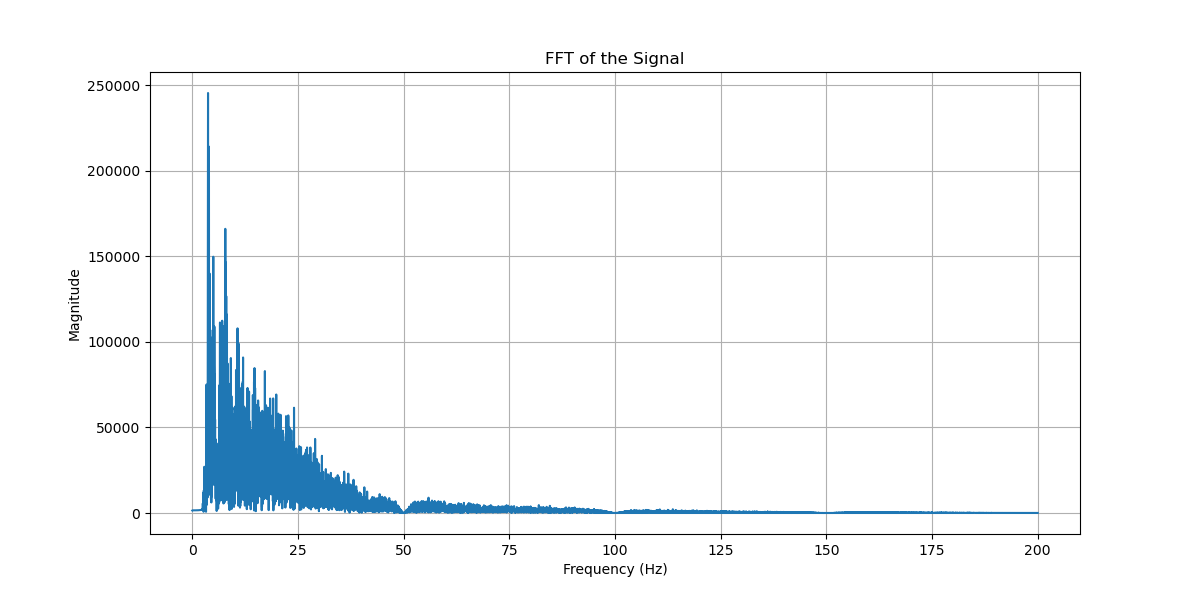

Frequency: 49.99 Hz, Magnitude: 161.55
Frequency: 100.00 Hz, Magnitude: 43.33
Frequency: 149.99 Hz, Magnitude: 13.58
Frequency: 199.98 Hz, Magnitude: 30.09


In [18]:
check_noise(s3.channel1)


In [20]:
s4 = changeSamplingRate(s3, 400, 2000)
sampling_rate = 2000  # Hz

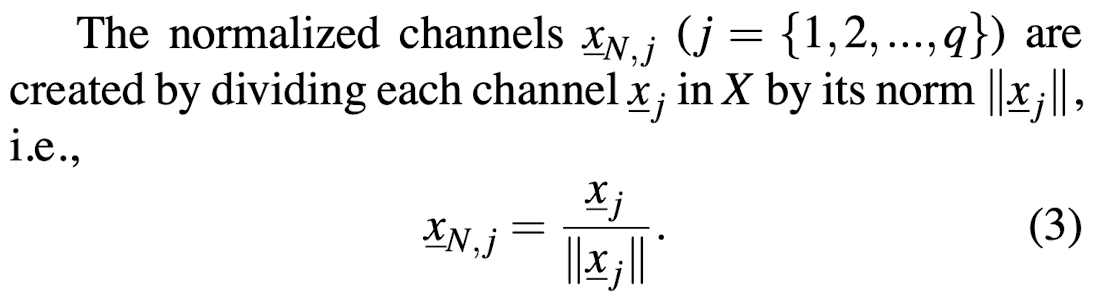

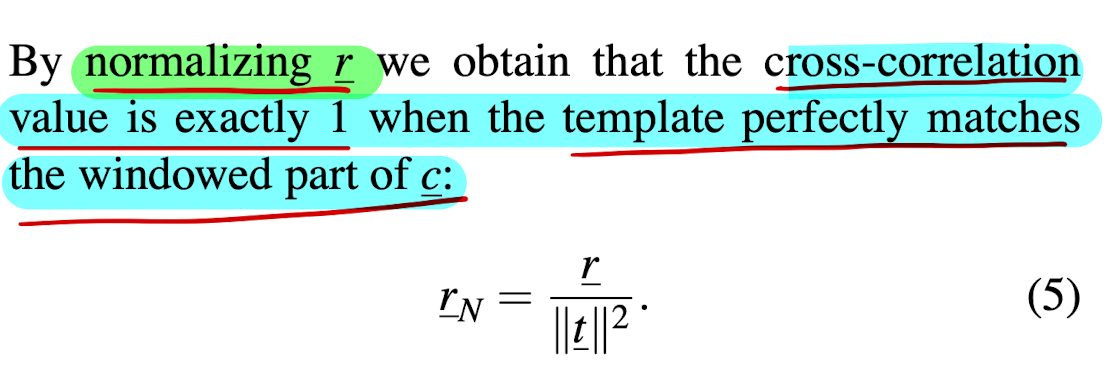

In [ ]:
def multi_channel_QRS_enhancement(fecg_df:pd.DataFrame,show_plot=False)->pd.DataFrame:
    """
    This function takes a dataframe of ECG and enhances the QRS complex in the signal.
    It uses PCA to extract the first principal component from the multi-channel ECG data.

    Args:
        fecg_df (pd.DataFrame): DataFrame containing the ECG data with columns ['time', 'channel1', 'channel2', 'channel3'].
        show_plot (bool): If True, plots the first principal component.

    Returns:
        np.ndarray: The first principal component of the multi-channel ECG data.
    """
    ecg_data = fecg_df.copy()  

    ecg_data.drop(columns=['time'], inplace=True)
    # print("Channel variance before normalization:")
    # print(ecg_data.var())
    # Step 1: Normalize the variance of each channel based on picture above
    normalized_data = ecg_data / np.linalg.norm(ecg_data, axis=0)
    # print("Channel variance after normalization:")
    # print(normalized_data.var())
    # Step 2: Perform PCA on the normalized data
    pca = PCA(n_components=1)  # Extract only the first principal component
    principal_component = pca.fit_transform(normalized_data)

    # Step 3: Plot the first principal component
    if show_plot:
        plt.figure(figsize=(12, 6))
        # plt.plot(ecg_data, label="ECG Data (3 Channels)", alpha=0.2)
        plt.plot(principal_component, label="First Principal Component (PC1)")
        plt.title("First Principal Component of Multi-Channel ECG Data")
        plt.xlabel("Samples")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.show()
    return principal_component

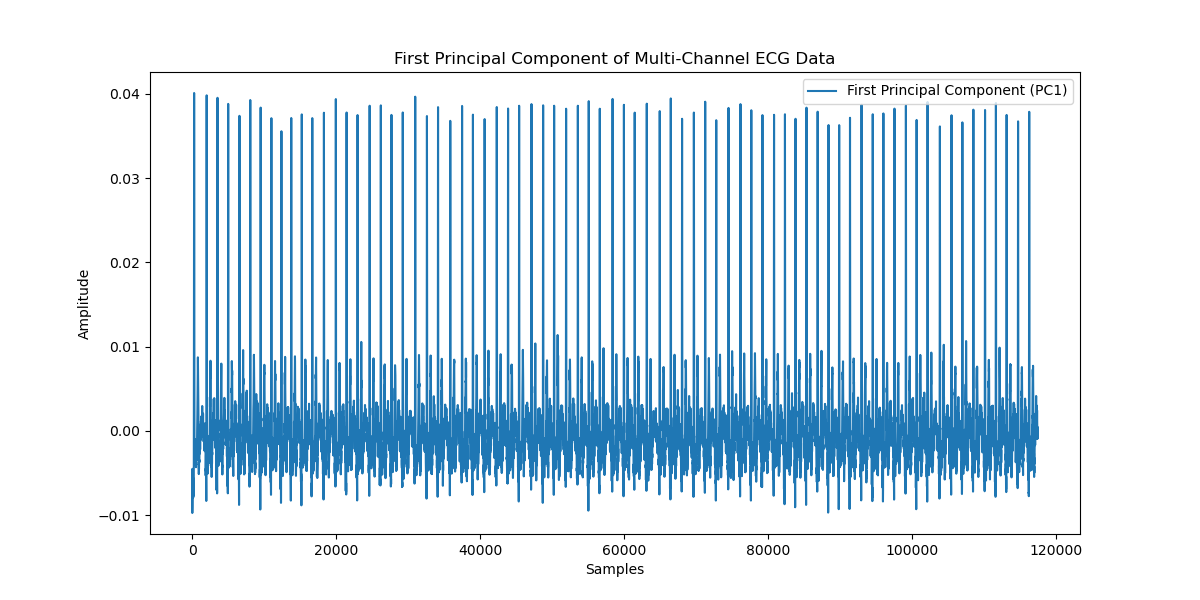

In [23]:
s4_pca = multi_channel_QRS_enhancement(s4,show_plot=True)

In [ ]:
    
def find_window_maxima(signal)-> np.array:
    """
    Finds the sample with the maximum absolute amplitude in each 1-second window.

    Args:
        signal (np.array): Input signal.

    Returns:
        List of indices of the maximum samples in each window.
    """
    window_size = 2000  # 1 second window at 2000 Hz
    maxima_indices = []

    for i in range(0, len(signal), window_size):
        window = signal[i:i + window_size]
        max_idx = np.argmax(np.abs(window)) + i  # Find index of max absolute amplitude
        maxima_indices.append(max_idx)

    return np.array(maxima_indices)

def extract_qrs_templates(signal, maxima_indices, fs)-> tuple :
    """
    Extracts QRS templates from the signal based on maxima indices.

    Args:
        signal (np.array): Input signal.
        maxima_indices (list): Indices of maxima in each window.
        fs (int): Sampling frequency in Hz.

    Returns:
        List of QRS templates (np.array) and their corresponding indices.
    """
    template_duration = 0.1  # in seconds
    template_samples = int(template_duration * fs)  # Number of samples in the template
    half_template = template_samples // 2

    templates = []
    template_indices = []

    for idx in maxima_indices:
        start = max(0, idx - half_template)  # Ensure index does not go negative
        end = min(len(signal), idx + half_template)  # Ensure index does not exceed signal length
        
        template = signal[start:end]

        if len(template) == template_samples:
            templates.append(template)
            template_indices.append(idx)
        else :
            # If the template is shorter than expected, we skip it
            print(f"Template at index {idx} is shorter than expected. Skipping.")
            # template = np.pad(template, (0, template_samples - len(template)), 'constant')
            # templates.append(template)
            # template_indices.append(idx)
            continue
  
    return np.array(templates), np.array(template_indices)

def compute_cross_correlation(signal, templates):
    """
    Computes the cross-correlation between the QRS templates and the signal.

    Args:
        signal (np.array): Input signal.
        templates (list of np.array): List of QRS templates.

    Returns:
        np.array: cross-correlation vector.
    """
    avg_template = np.mean(templates, axis=0)
    r = correlate(signal, avg_template, mode="same")
    template_energy = np.linalg.norm(avg_template) ** 2
    cross_correlation = r / template_energy # Normalize the cross-correlation 

    return cross_correlation

def threshold_cross_correlation(cross_correlation, threshold):
    """
    Applies thresholding to identify QRS candidates from cross-correlation results.

    Args:
        cross_correlation (np.array): Cross-correlation vector.
        threshold (float): Threshold value for QRS detection.

    Returns:
        np.array: Indices where QRS candidates are detected.
    """
    # Find indices where correlation exceeds the threshold
    qrs_candidates = np.where(cross_correlation > threshold)[0]
    return qrs_candidates

def refine_qrs_candidates(qrs_candidates, cross_correlation, fs, min_distance):
    """
    Refines QRS candidates based on realistic spacing between beats.

    Args:
        qrs_candidates (np.array): QRS candidate indices.
        cross_correlation (np.array): Cross-correlation vector.
        fs (int): Sampling frequency in Hz.
        min_distance (float): Minimum distance between QRS peaks (in seconds).

    Returns:
        np.array: Refined QRS peak positions.
    """
    refined_positions = []
    prev_index = -np.inf  # Track last valid QRS peak

    for idx in qrs_candidates:
        if idx - prev_index > min_distance * fs:
            refined_positions.append(idx)
            prev_index = idx
        else:
            # Keep the candidate with the highest correlation
            if cross_correlation[idx] > cross_correlation[prev_index]:
                refined_positions[-1] = idx
                prev_index = idx

    return np.array(refined_positions)

In [ ]:
def QRS_detector(pca: pd.DataFrame, sampling_rate=2000,threshold = 0.5, min_distance = 0.5, show_plot=False):
    """
    Detects the QRS complexes from a multi-channel ECG signal.

    Args:
        pca (pd.DataFrame): Multi-channel ECG dataframe.
        sampling_rate (int): Sampling frequency (Hz).
        show_plot (bool): If True, plots QRS detection.
        threshold (float): Threshold for QRS detection.
        min_distance (float): Minimum distance between QRS peaks (in seconds).

    Returns:
        np.array: Detected QRS peak indices.
    """

    # Step 2: Find Maxima in 1-Second Windows**
    maxima_indices = find_window_maxima(pca)

    # Step 3: Extract QRS Templates**
    templates,_ = extract_qrs_templates(pca, maxima_indices, sampling_rate)

    # Step 4: Compute Cross-Correlation**
    cross_correlations = compute_cross_correlation(pca, templates)  # Single array now
 
    # Step 5: Apply Thresholding**
    qrs_candidates = threshold_cross_correlation(cross_correlations, threshold)

    # Step 6: Refine QRS Candidates**
    refined_qrs_positions = refine_qrs_candidates(qrs_candidates, cross_correlations, sampling_rate, min_distance)

    if show_plot:
        time_axis = np.arange(len(pca)) / sampling_rate  # Convert samples to time
        plt.figure(figsize=(12, 5))
        plt.plot(time_axis, pca, label="Enhanced QRS Signal", alpha=0.8)
        plt.scatter(refined_qrs_positions / sampling_rate, pca[refined_qrs_positions],
                    color='red', marker='o', label="Detected QRS Peaks")
        
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.title("QRS Detection")
        plt.legend()
        plt.grid()
        plt.show()

    return refined_qrs_positions

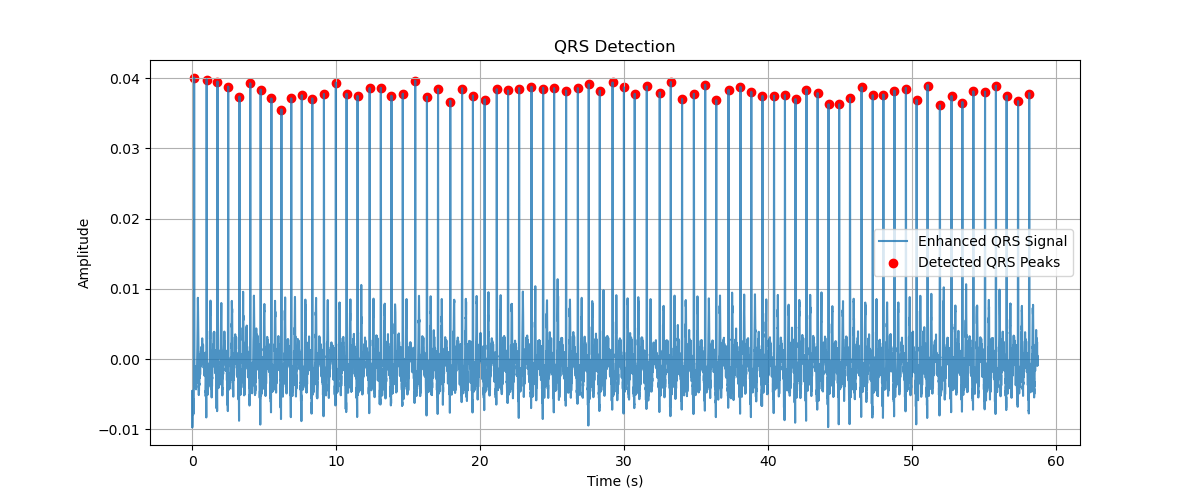

In [27]:
qrs_peaks = QRS_detector(s4_pca,sampling_rate=2000, show_plot=True)

In [28]:
print(f"Estimated maternal HR: {len(qrs_peaks)} bpm")

Estimated maternal HR: 75 bpm


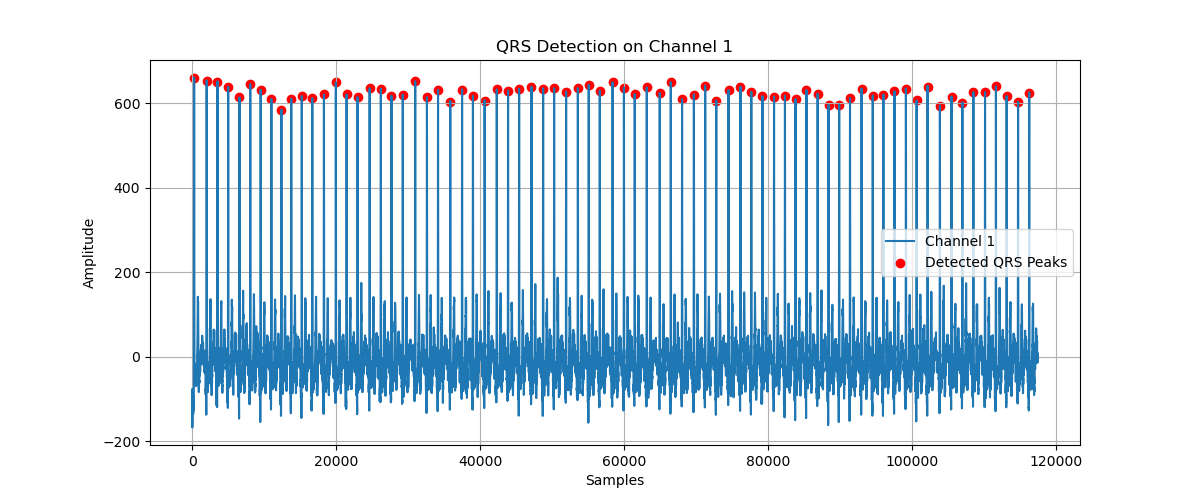

In [49]:
#plot the detected QRS peaks 
plt.figure(figsize=(12, 5))
plt.plot(s4.channel1, label="Channel 1")
plt.scatter(qrs_peaks, s4.channel1[qrs_peaks], color='red', marker='o', label="Detected QRS Peaks")

plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.title("QRS Detection on Channel 1")
plt.legend()
plt.grid()
plt.show()

In [ ]:

def extract_mecg_windows(signal, qrs_peaks, fs, pre_qrs=0.25, post_qrs=0.45):
    """
    Extracts MECG windows around each QRS peak.

    Args:
        signal (np.array): Enhanced ECG signal.
        qrs_peaks (np.array): Detected QRS indices.
        fs (int): Sampling frequency in Hz.
        pre_qrs (float): Seconds before the QRS to start the window.
        post_qrs (float): Seconds after the QRS to end the window.

    Returns:
        List of MECG window arrays and their original indices.
    """
    window_size = int((pre_qrs + post_qrs) * fs)
    half_pre = int(pre_qrs * fs)
    windows = []
    indices = []

    for peak in qrs_peaks:
        if peak - half_pre < 0:
            continue
        start = peak - half_pre  # Start of the window
        if start + window_size > len(signal):
            continue
        end = start + window_size  # End of the window
        windows.append(signal[start:end])
        indices.append((start, end))

    return windows, indices

def compute_least_min_square(mu_P, mu_QRS, mu_T, m,print_scaling=False,index=None):
    """
    Constructs M using zero-padded block columns for mu_P, mu_QRS, and mu_T,
    Solves the least-squares problem to estimate m_hat (estimated MECG).

    Args:
        mu_P (np.array): Mean P wave segment.
        mu_QRS (np.array): Mean QRS complex segment.
        mu_T (np.array): Mean T wave segment.
        m (np.array): Current window segment to estimate.
        print_scaling (bool): If True, prints the scaling factor.
        index (int): Index for debugging purposes.
    
    Returns:
        np.array: Estimated MECG segment (m_hat).
    """

    # Determine the lengths
    len_P = len(mu_P)
    len_QRS = len(mu_QRS)
    len_T = len(mu_T)

    # Pad mu_P: on bottom
    col_P = np.concatenate([mu_P, np.zeros(len_QRS + len_T)])

    # Pad mu_QRS: top and bottom
    col_QRS = np.concatenate([np.zeros(len_P), mu_QRS, np.zeros(len_T)])

    # Pad mu_T: on top
    col_T = np.concatenate([np.zeros(len_P + len_QRS), mu_T])

    # Stack to form M matrix: shape (total_len, 3)
    M = np.column_stack([col_P, col_QRS, col_T])
    
    if index ==20:
        plt.figure(figsize=(10, 5))
        plt.imshow(M, aspect='auto', cmap='gray_r', interpolation='none')
        plt.xlabel('Segment (P, QRS, T)')
        plt.ylabel('Samples')
        plt.title('Matrix M Visualization')
        plt.colorbar(label='Amplitude')
        plt.show()

    # Solve least-squares: a = (M.T M)**-1 M.T m
    MTM = M.T @ M

    MTm = M.T @ m
    a = np.linalg.pinv(MTM) @ MTm
    m_hat = M @ a
    if print_scaling:
        print(f"scaling factor for index {index} : {a}")
        plt.figure(figsize=(12, 6))
        plt.plot(m, label="m full")
        plt.title("m_full") 
        plt.xlabel("Samples")   
        plt.ylabel("Amplitude")
        plt.legend()    
        plt.grid()
        plt.show()

    return m_hat 

def mecg_cancellation(ecg_df,qrs_peaks, fs, N=10):
    """
    Applies MECG cancellation using scaling of P, QRS, T wave and subtracts only where m̂ is defined.

    Args:
        ecg_df (pd.DataFrame): Dataframe containing the ECG signal.
        qrs_peaks (dict): QRS peak positions detected from PC1.
        fs (int): Sampling frequency in Hz.
        N (int): Number of windows to average for scaling.

    Returns:
        pd.DataFrame: Dataframe with cleaned ECG signal.
    """
    cleaned_signal = ecg_df.copy()
    windows_per_channel = {}
    skipped_windows_per_channel = {}
    # Extract MECG windows
    for column in cleaned_signal.columns:
        if column == 'time':
            continue
        signal = cleaned_signal[column].values
        windows, window_indices = extract_mecg_windows(signal,qrs_peaks,fs)

        # print(len(windows[0]))
        # windows_per_channel[column] = windows
        # mu_test = np.mean(windows[10:20], axis=0)
        # plt.figure(figsize=(12, 6))
        # for i in range(10, 20):
        #     plt.plot(windows_per_channel[column][i], label=f"Window {i+1}", alpha=0.2)
        # plt.plot(mu_test, label="Mean Window", color='red', linewidth=2)
        # plt.title(f"window extraction for {column}") 
        # plt.xlabel("Samples")
        # plt.ylabel("Amplitude") 
        # plt.legend()
        # plt.grid()
        # plt.show()
    
        for i in range(N, len(windows)):
            m = windows[i]
            mu = np.mean(windows[i - N:i], axis=0)

            # Extract P, QRS, T segments
            # fs = 2000 Hz
            # P: 0.15s before QRS
            # QRS: 0.05s before and after R 
            # T: 0.35s after QRS
            qrs_center = int(0.25 * fs) # 0.25s after the start of the window -> R 
            # QRS = R ± 0.05s
            qrs_start = qrs_center - int(0.05 * fs)
            qrs_end   = qrs_center + int(0.05 * fs)

            # P wave: 0.20s before QRS window
            p_start = qrs_start - int(0.2 * fs)
            p_end   = qrs_start

            # T wave: 0.40s after QRS window
            t_start = qrs_end
            t_end   = qrs_end + int(0.4 * fs)

            # From averaged window (μ)
            mu_P   = mu[p_start:p_end]
            mu_QRS = mu[qrs_start:qrs_end]
            mu_T   = mu[t_start:t_end]

            # From current window (m)
            m_P   = m[p_start:p_end]
            m_QRS = m[qrs_start:qrs_end]
            m_T   = m[t_start:t_end]

            m_full = np.concatenate([m_P, m_QRS, m_T])
            
            # Use least-min-square estimator
            m_hat = compute_least_min_square(mu_P, mu_QRS, mu_T, m_full)
            
            # plot the original and estimated signals
            # if i ==43:
            #     plt.figure(figsize=(12, 6))
            #     plt.plot(m_full, label="Original Window", alpha=0.5)
            #     plt.plot(m_hat, label="Estimated Window", color='red', linewidth=2)
            #     plt.title(f"Window index {i} for {column}") 
            #     plt.xlabel("Samples")
            #     plt.ylabel("Amplitude") 
            #     plt.legend()
            #     plt.grid()
            #     plt.show()


            start, end = window_indices[i]

            # Subtract m_hat from the original signal if it is a good estimate
            # Check if the estimated signal is close to the original
            corr = np.corrcoef(m_full, m_hat)[0, 1]
            if corr > 0.70:
                signal[start:end] -= m_hat
            else:
                # If the correlation is low, skip this window
                if column not in skipped_windows_per_channel:
                    skipped_windows_per_channel[column] = []
                skipped_windows_per_channel[column].append(window_indices[i])
                print(f"Skipped window {i} for {column} due to low correlation: {corr:.2f}")
                continue
        
        # Remove the first 10 peaks
        for i in range(N):
            m = windows[i] 
            mu = np.mean(windows[0:10], axis=0)
            qrs_center = int(0.25 * fs)
            
            
            # QRS = R ± 0.05s
            qrs_start = qrs_center - int(0.05 * fs)
            qrs_end   = qrs_center + int(0.05 * fs)

            # P wave: 0.20s before QRS window
            p_start = qrs_start - int(0.2 * fs)
            p_end   = qrs_start

            # T wave: 0.40s after QRS window
            t_start = qrs_end
            t_end   = qrs_end + int(0.4 * fs)

            # From averaged window (μ)
            mu_P   = mu[p_start:p_end]
            mu_QRS = mu[qrs_start:qrs_end]
            mu_T   = mu[t_start:t_end]

            # From current window (m)
            m_P   = m[p_start:p_end]
            m_QRS = m[qrs_start:qrs_end]
            m_T   = m[t_start:t_end]

            m_full = np.concatenate([m_P, m_QRS, m_T])

            # Use least-min-square estimator
            m_hat = compute_least_min_square(mu_P, mu_QRS, mu_T, m_full)

            # Subtract m_hat from the original signal
            start, end = window_indices[i]
            # Subtract m_hat from the original signal if it is a good estimate
            # Check if the estimated signal is close to the original
            corr = np.corrcoef(m_full, m_hat)[0, 1]
            if corr > 0.70:
                signal[start:end] -= m_hat
            else:
                # If the correlation is low, skip this window
                if column not in skipped_windows_per_channel:
                    skipped_windows_per_channel[column] = []
                skipped_windows_per_channel[column].append(window_indices[i])
                print(f"Skipped window {i} for {column} due to low correlation: {corr:.2f}")
                continue
            

        # Update the cleaned signal in the dataframe
        cleaned_signal[column] = signal
        # Update the cleaned signal in the dataframe
        cleaned_signal[column] = signal


    return cleaned_signal,skipped_windows_per_channel


In [34]:
s5,skipped_windows_per_channel = mecg_cancellation(s4,qrs_peaks,sampling_rate,N=10)

Skipped window 20 for channel1 due to low correlation: 0.34
Skipped window 20 for channel2 due to low correlation: 0.34
Skipped window 20 for channel3 due to low correlation: 0.34
Skipped window 20 for channel4 due to low correlation: 0.34


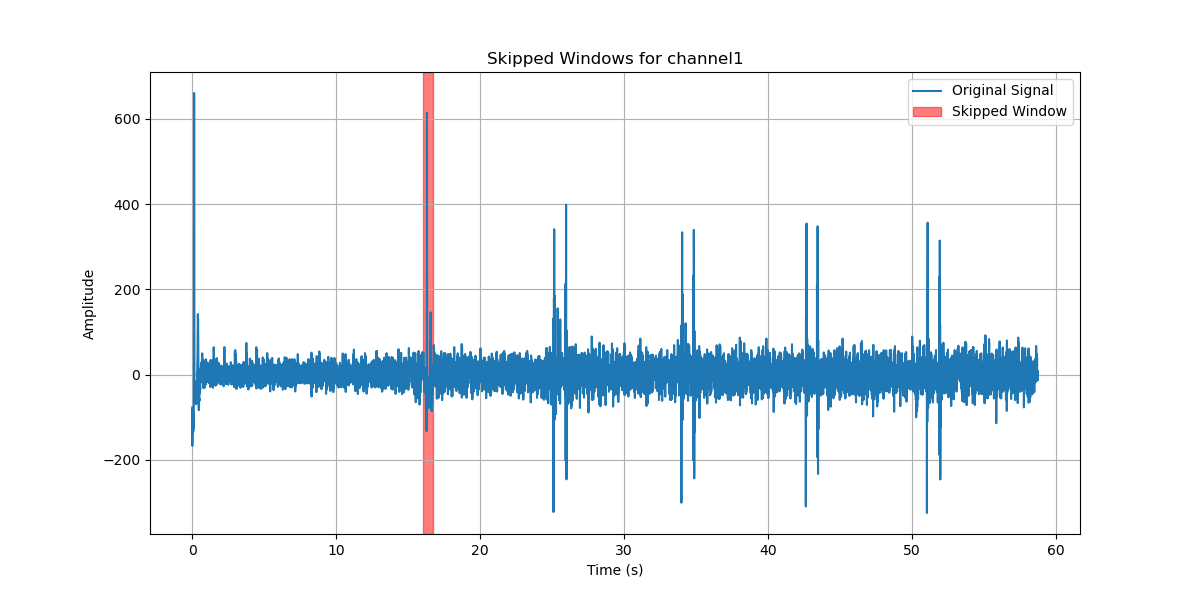

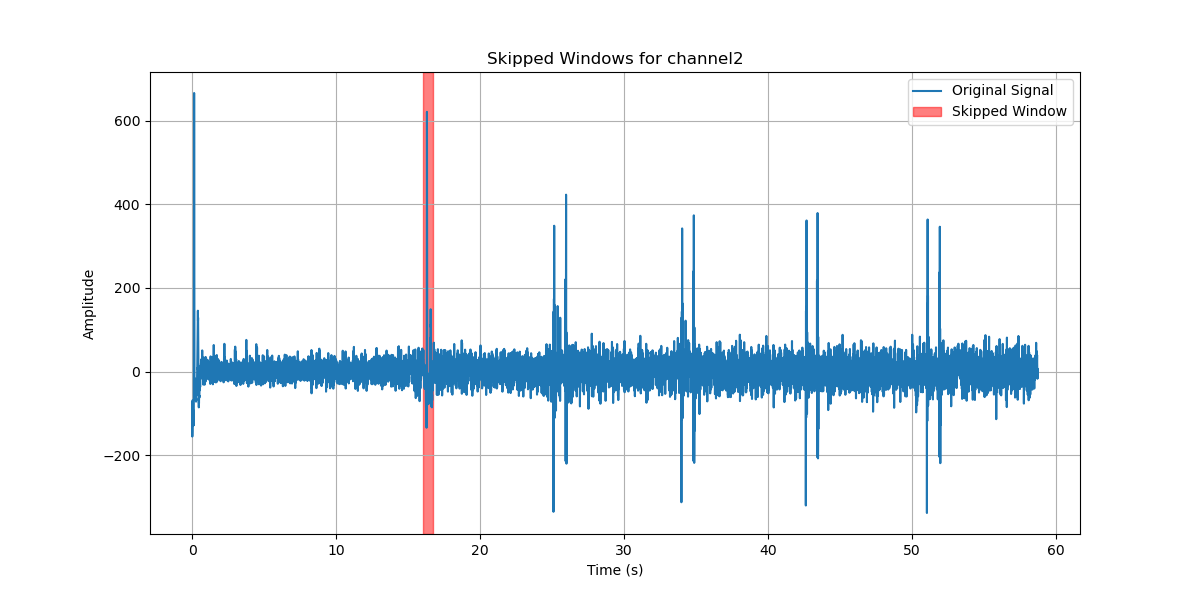

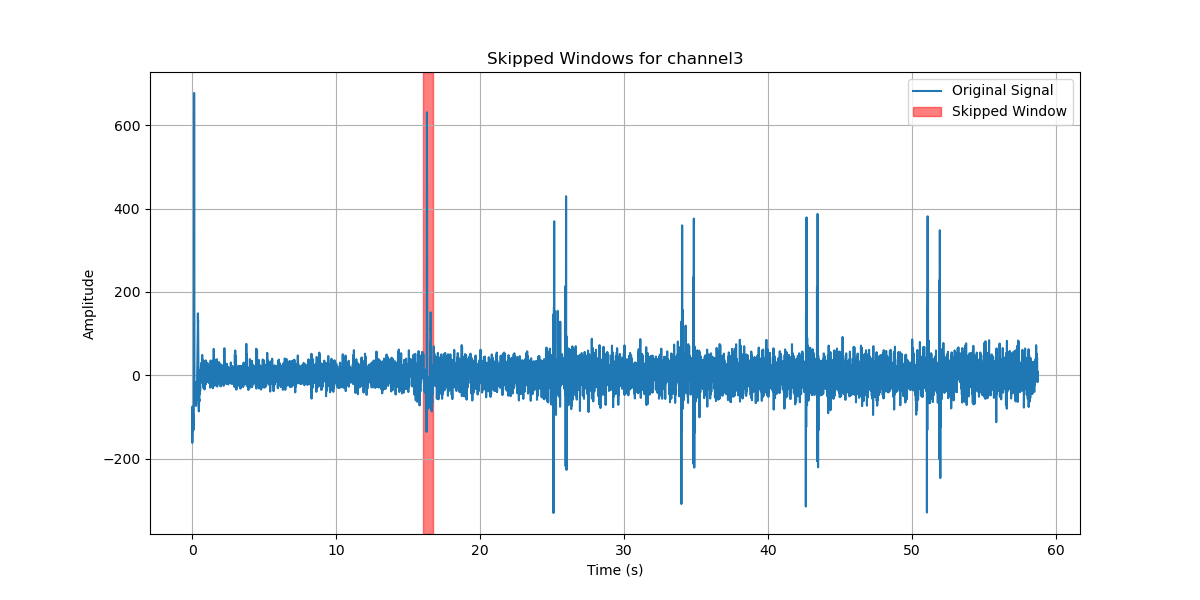

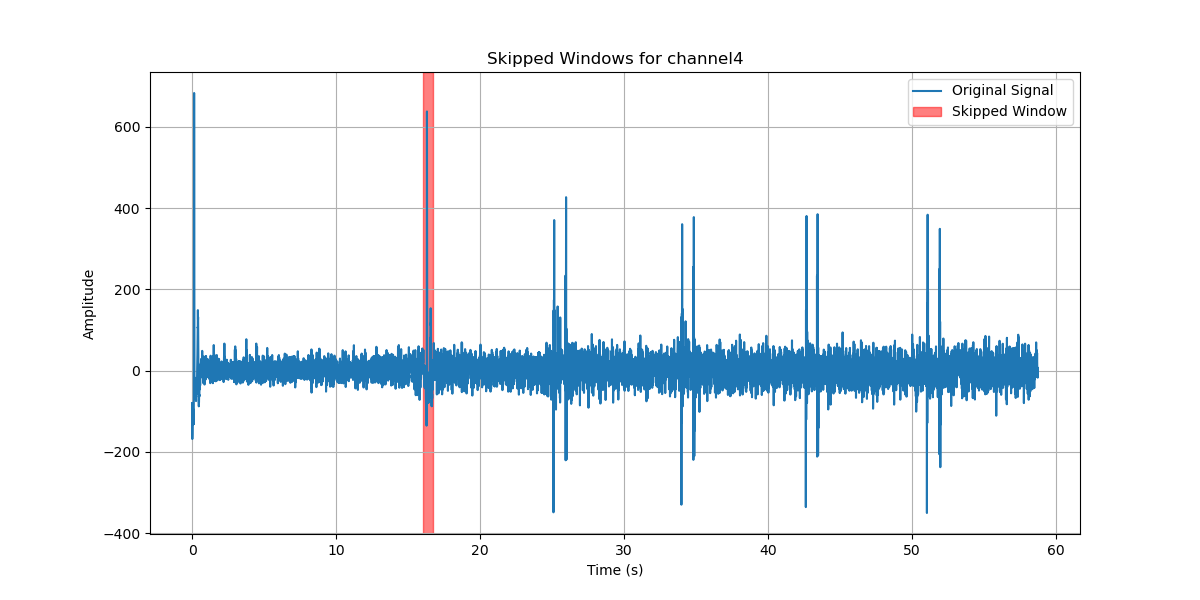

In [ ]:
def plot_skipped_windows(skipped_windows_per_channel, fs, signal):
    """
    Plots the skipped windows for each channel.

    Args:
        skipped_windows_per_channel (dict): Dictionary of skipped windows for each channel.
        fs (int): Sampling frequency in Hz.
        signal (np.array): Original signal to plot.
    """
    time = np.arange(len(signal)) / fs

    for channel, windows in skipped_windows_per_channel.items():
        plt.figure(figsize=(12, 6))
        plt.plot(time, signal[channel], label="Original Signal")
        for start, end in windows:
            plt.axvspan(start / fs, end / fs, color='red', alpha=0.5, label="Skipped Window")
        plt.title(f"Skipped Windows for {channel}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid()
        plt.show()
        
plot_skipped_windows(skipped_windows_per_channel, sampling_rate, s5)

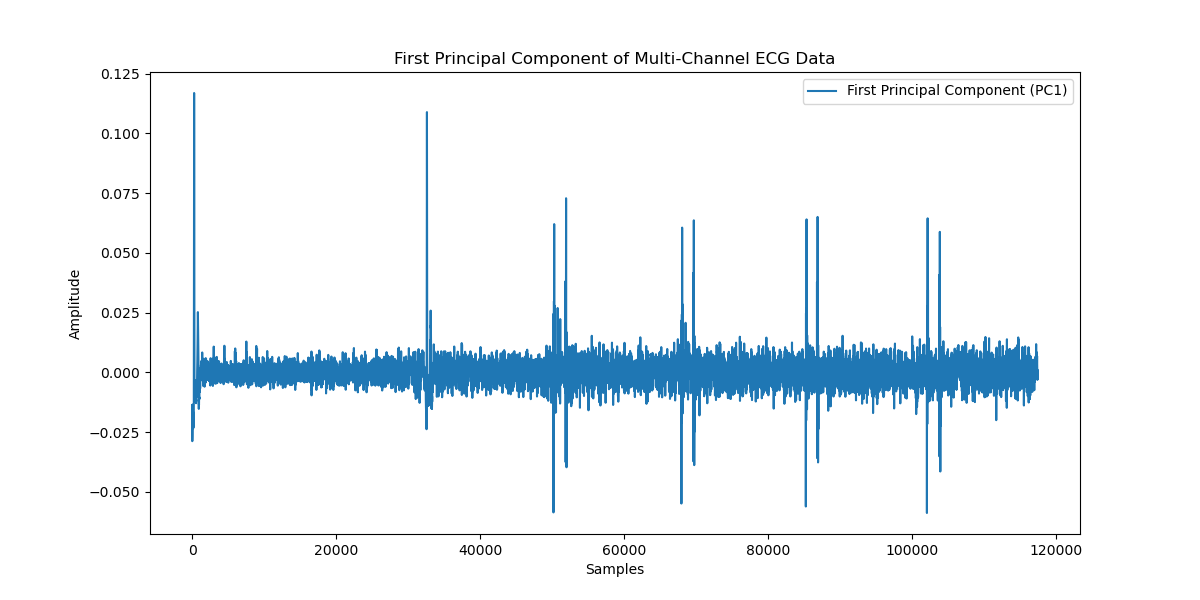

In [36]:
s5_pca = multi_channel_QRS_enhancement(s5,show_plot=True)


In [37]:
def plot_mecg_removal_example(enhanced_signal,cleaned_signal, qrs_peaks, fs, i=10):
    """
    Visualizes one example of MECG cancellation by comparing the original and cleaned signals
    in a window around a selected QRS peak.
    
    Args:
        enhanced_signal (np.ndarray): Original signal before subtraction
        cleaned_signal (np.ndarray): Signal after MECG subtraction
        qrs_peaks (np.ndarray): Detected QRS peaks
        fs (int): Sampling frequency
        i (int): Index of QRS peak to visualize
    """
    pre_qrs = int(0.25 * fs)
    post_qrs = int(0.45 * fs)
    center = qrs_peaks[i]
    start = center - pre_qrs
    end = center + post_qrs

    t = np.arange(start, end) / fs
    plt.figure(figsize=(12, 4))
    plt.plot(t, enhanced_signal[start:end], label="Before Cancellation (Enhanced)", alpha=0.6)
    plt.plot(t, cleaned_signal[start:end], label="After Cancellation (Cleaned)")
    plt.axvline(center / fs, color='r', linestyle='--', label='QRS Center')
    plt.title(f"MECG Cancellation Example (QRS index: {i})")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

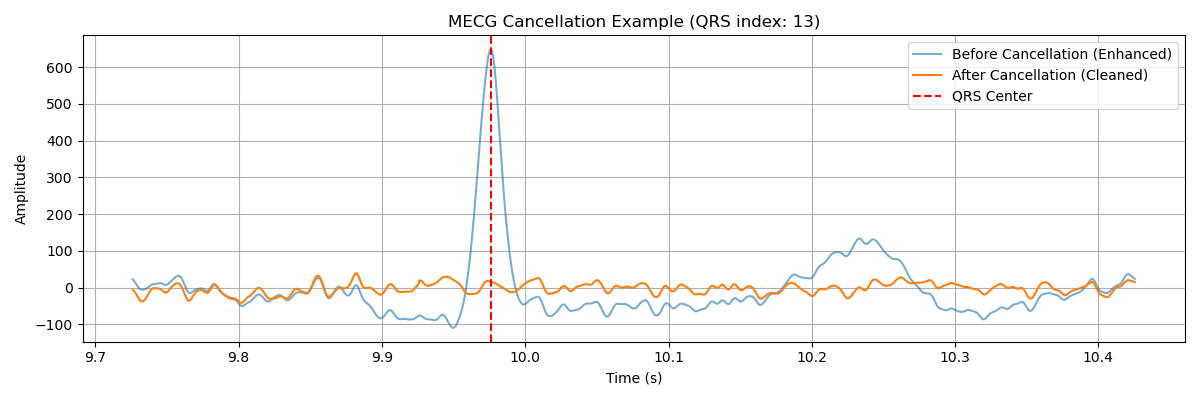

In [38]:
plot_mecg_removal_example(s4.channel1,s5.channel1,qrs_peaks,sampling_rate,i=13)

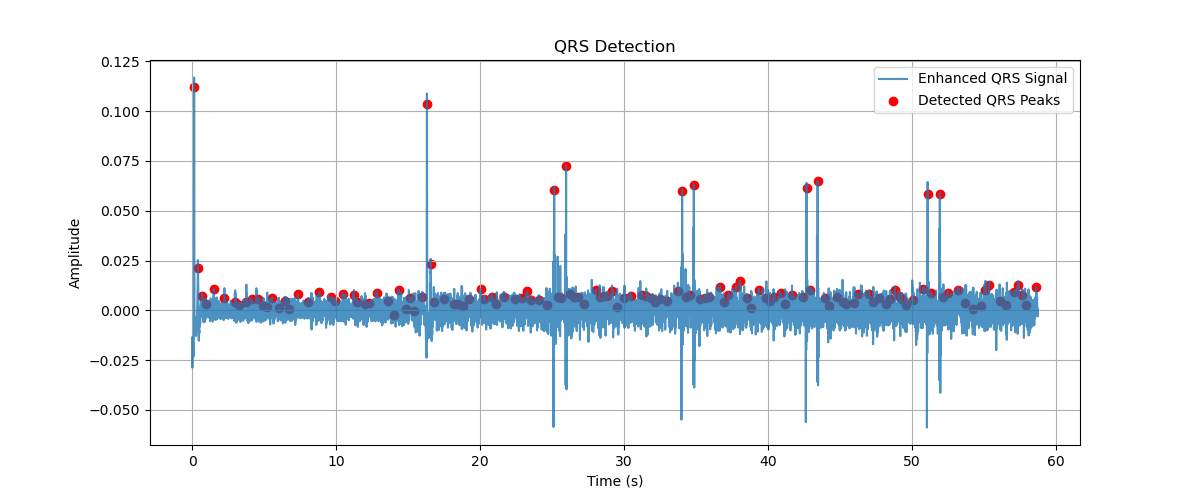

In [39]:
qrs_peaks_fetal = QRS_detector(s5_pca,sampling_rate=2000, show_plot=True,threshold=0.3, min_distance=0.25)

In [40]:
len(qrs_peaks_fetal)

138

In [41]:
def average_fecg_complex(cleaned_ecg_df, fetal_qrs_peaks, fs):
    """
    Computes the average FECG complex for each channel over fetal QRS peaks.
    
    Args:
        cleaned_ecg_df (pd.DataFrame): MECG-cancelled multi-channel ECG.
        fetal_qrs_peaks (np.array): Detected fetal QRS indices.
        fs (int): Sampling frequency in Hz.
        window_sec (float): Total window length in seconds (e.g., 0.6s).
    
    Returns:
        dict: {channel_name: avg_fecg_segment (np.array)}
    """

    avg_complexes = pd.DataFrame()
    

    for col in cleaned_ecg_df.columns:
        if col == "time":
            continue

        segments = []
        signal = cleaned_ecg_df[col].values

        for peak in fetal_qrs_peaks:
            start = peak - int(0.25 * fs)  # 0.25s before the peak
            end = peak + int(0.45 * fs)  # 0.45s after the peak

            if start >= 0 and end < len(signal):
                segments.append(signal[start:end])

        if segments:
            avg_complex = np.mean(segments, axis=0)
            avg_complexes[col] = avg_complex

    return avg_complexes


In [42]:
average_fecg_complexes = average_fecg_complex(s5, qrs_peaks_fetal, fs=2000)

In [43]:
average_fecg_complexes.head()

,channel1,channel2,channel3,channel4
0,22.990687,23.783890,24.504716,24.733988
1,21.941471,22.721546,23.468622,23.658486
2,20.870443,21.616617,22.383649,22.535165
3,19.767826,20.460806,21.231475,21.347716
4,18.632301,19.257352,20.007941,20.093113


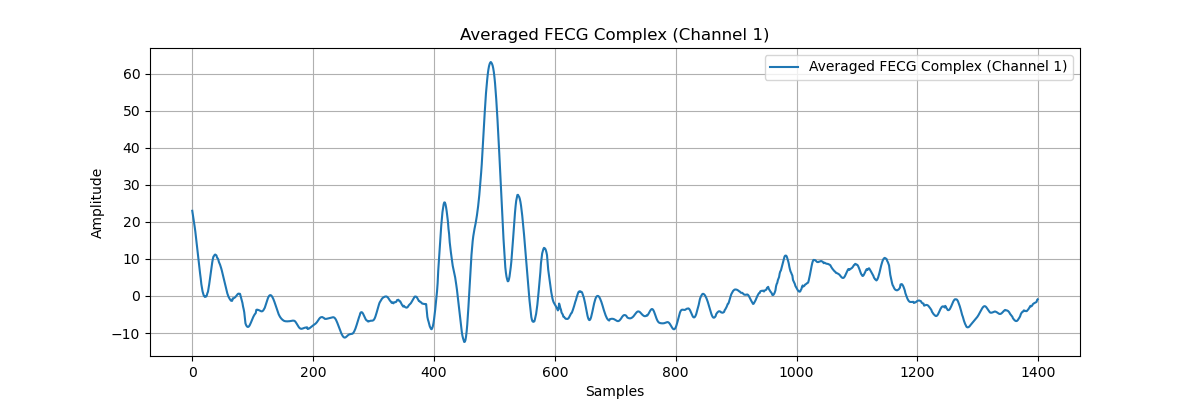

In [61]:
plt.figure(figsize=(12, 4))
plt.plot(average_fecg_complexes.channel1, label="Averaged FECG Complex (Channel 1)")
plt.title("Averaged FECG Complex (Channel 1)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()
plt.show()

In [45]:
def compute_final_avg_fecg(avg_complexes):
    return np.mean(avg_complexes, axis=1).values


In [ ]:
final_avg_fecg = compute_final_avg_fecg(average_fecg_complexes)

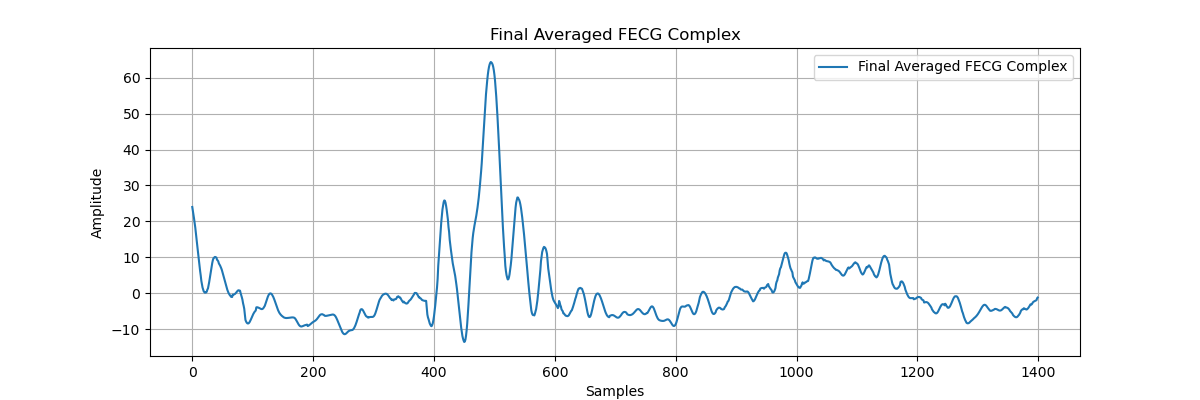

In [62]:
plt.figure(figsize=(12, 4))
plt.plot(final_avg_fecg, label="Final Averaged FECG Complex")
plt.title("Final Averaged FECG Complex")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()
plt.show()